In [4]:
import pandas as pd
import numpy as np
import pickle 
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots

def load_results(path):
    with open(path, 'rb') as file:
            results = pickle.load(file)

    tools = ['Avatars K5', "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", "TVAE"]
    indexes = [0.1, 0.25, 0.5, 0.75, 1]
    df_results = pd.DataFrame(results).T
    df_results.columns = ['25%', '50%', '75%', '100%']
    df_results.index = tools

    return df_results 

In [3]:
cancers = ['ccRCC', 'Melanoma', 'NSCLC']
seed = 42
ResultDict = {}
for cancer in cancers:
    path = f'../{cancer}/Privacy/Linkability/Seed_{seed}/LinkabilityResults.pkl'
    df_result = load_results(path)
    ResultDict[cancer] = df_result

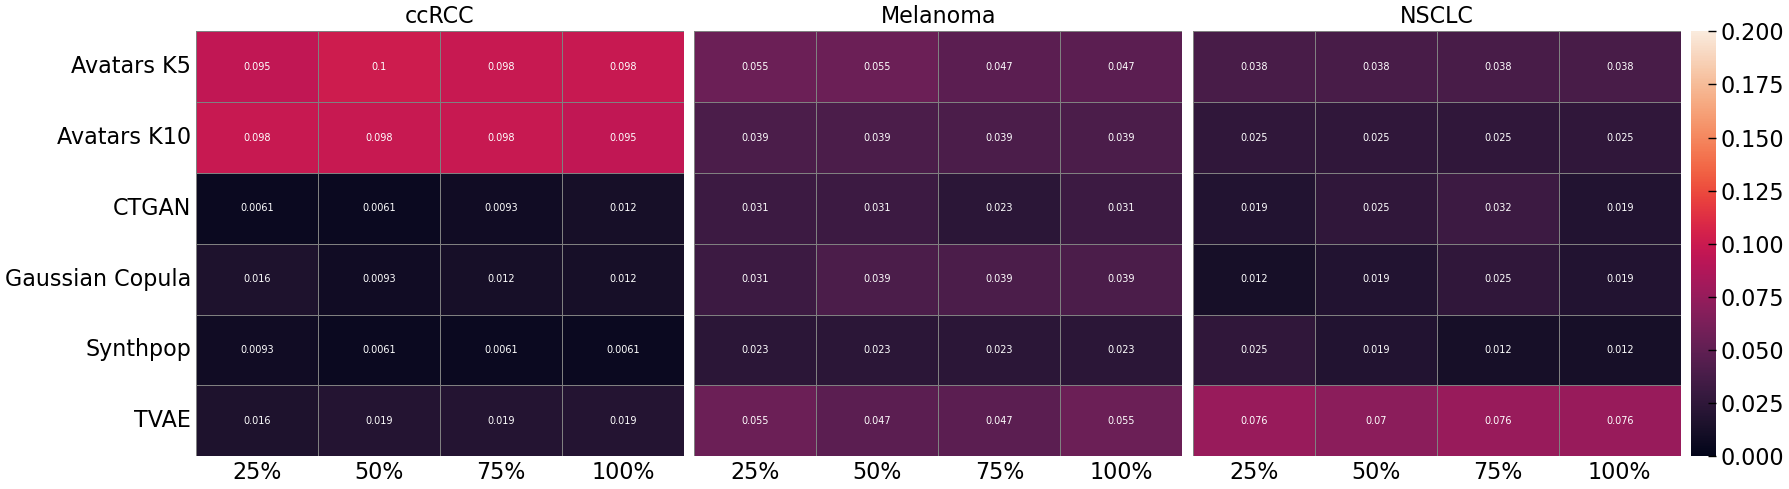

In [8]:
plt.style.use(["science", "nature", "notebook", {"image.cmap": "inferno"}])
plt.rcParams.update({'text.usetex': False})
plt.rcParams['xtick.minor.visible'] = False
plt.rcParams['ytick.minor.visible'] = False

fig, axes = plt.subplots(1, 4, figsize=(18, 5),
                         gridspec_kw={'width_ratios': [1, 1, 1, 0.05]})

ax1, ax2, ax3, cbar_ax = axes

vmin, vmax = 0, 0.2
line_params = {'linewidths': 0.5, 'linecolor': 'gray',}
# heatmap
sns.heatmap(ResultDict['ccRCC'], ax=ax1, cbar=False, vmin=vmin, vmax=vmax, **line_params,annot=True)
sns.heatmap(ResultDict['Melanoma'], ax=ax2, cbar=False, vmin=vmin, vmax=vmax,yticklabels=False,**line_params,annot=True)
# Vẽ heatmap thứ 3 vào ax3, nhưng chỉ định thanh màu vẽ vào cbar_ax
sns.heatmap(ResultDict['NSCLC'], ax=ax3, cbar_ax=cbar_ax, vmin=vmin, vmax=vmax,yticklabels=False,**line_params,annot=True)

ax1.set_title('ccRCC')
ax2.set_title('Melanoma')
ax3.set_title('NSCLC')

for ax in [ax1, ax2, ax3]:
    # Loại bỏ hoàn toàn các vạch chia nhỏ
    ax.tick_params(which='major', top=False, bottom=False, left=False, right=False)

plt.tight_layout()
plt.show()